# UMAP as an Alternative Distance Metric Sub-Experiment

## Motivation

Every Lipschitz estimate in this project reduces to the same ratio,
`|margin_i - margin_j| / distance(x_i, x_j)` -- and every metric tried so
far for the denominator has been a *hand-built* distance: plain Euclidean
in raw pixel space, a ridge-regularized Mahalanobis distance fit from the
pixel covariance (`distance.py`), or Euclidean distance applied to a fixed
pixel-space feature map (`embeddings.py::elementwise_embedding`,
`local_patch_cross_terms` -- see `README.md`'s ratio-distribution and
embedding-degree-sweep sections for what those found).

UMAP is a different kind of candidate: instead of a formula, it *learns* a
low-dimensional embedding by directly optimizing for one specific
property -- that points close together in the original space stay close
together in the embedding, and vice versa. If that optimization actually
succeeds on MNIST, Euclidean distance in the embedded space is a
plausible, principled alternative "local similarity" metric to plug into
this project's existing ratio-distribution machinery, without hand-tuning
a formula or fitting a covariance matrix.

**This sub-experiment is additive to the main experiment
(`notebook_mnist_lipschitz.ipynb`) and the layer-decomposition
sub-experiment (`notebook_layer_decomposition.ipynb`), not a replacement
for either** -- same convention: dedicated `.py` module
(`umap_embedding.py`) plus this thin driver notebook, since "is a learned
embedding a good distance metric here" is a structurally distinct
question from both.

## Important: unsupervised UMAP only, and why

UMAP also supports a **supervised** mode, using class labels directly
during fitting (`umap.UMAP(...).fit(x, y)`) -- which would very plausibly
produce visibly cleaner per-digit clustering almost by construction, since
the labels are then part of what's being optimized for. This notebook
and `umap_embedding.py` use **unsupervised UMAP only**: no labels are ever
passed to `.fit()`. Whether supervised UMAP is actually the variant wanted
here is an **open question for Nick/Terry, not decided in this
notebook** -- an embedding built *from* the labels changes the question
being asked (closer to "does the model separate points the way the labels
already say to" than "does an unsupervised notion of local similarity
predict margin sensitivity"), and picking one silently would answer a
different question than may have been intended. See
`umap_embedding.py`'s module docstring for the same note in more detail.

## What this notebook does

1. **Fit** an unsupervised UMAP embedding on a modest training-set subset
   (not the full 60k -- UMAP fitting cost scales with dataset size, and
   this project's convention elsewhere is to keep exploratory new-metric
   work on a manageable subset).
2. **Validate** it before trusting it as a metric at all: embed a
   class-stratified test subset and check for visible per-digit
   clustering, both visually and with a quantitative k-NN label-purity
   check -- a scattered/mixed result would mean stopping here.
3. **Compare**, if validation passes: reuse the existing
   `run_experiment.py::run_ratio_distribution_analysis` unchanged, with a
   UMAP-embedded-space Euclidean `distance_fn` in place of raw-pixel
   Euclidean/Mahalanobis, on logistic regression -- same 1000-point
   stratified subset / k=5 near-neighbors setup as every other
   ratio-distribution comparison in this project, for direct numeric
   comparability against the raw-pixel Euclidean baseline already in
   `README.md`.

This is a thin driver notebook -- all reusable logic lives in
`umap_embedding.py` (fitting, the embed_fn/distance_fn wrappers, the
label-purity check) and `plots.py` (the validation scatter plot). This
notebook only calls into them and displays results.

In [1]:
%pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

import torch

from mnist_lipschitz.data import load_mnist, get_dev_subset, make_loader, stratified_subset_idx
from mnist_lipschitz.models import LogisticRegressionModel, train_classifier
from mnist_lipschitz import umap_embedding, run_experiment, plots

SEED = 0
torch.manual_seed(SEED)
train = load_mnist(train=True)
test = load_mnist(train=False)

## Fit the UMAP embeddings

Two separate fits, both unsupervised, both on the same 3000-point training
dev subset (`get_dev_subset` -- not the full 60k, see Motivation above):

- **5D**, `n_components=5` -- the embedding actually used for the distance
  metric in Step 3 below.
- **2D**, `n_components=2` -- a *separate* fit, purely for the validation
  scatter plot in Step 2. Taking the first two dimensions of the 5D
  embedding instead would be a misleading substitute: UMAP's output
  dimensions aren't ordered by variance the way PCA's are, so an arbitrary
  2-of-5 slice could look artificially scattered even if the full 5D
  embedding is well-structured (or vice versa). A dedicated 2D fit is
  UMAP's own recommended practice for visualization, and is the choice
  made here -- documented explicitly rather than picked silently, per
  `umap_embedding.py`'s docstring convention.

A real segfault (numba/torch OpenMP thread-pool conflict, the same class
of issue this project's `run_ratio_distribution_analysis` already works
around for sklearn) was hit and fixed while building `umap_embedding.py` --
see that module's docstring; nothing extra needs doing here, the
workaround is set at import time.

In [3]:
dev = get_dev_subset(train, n=3000, seed=SEED)

reducer_5d = umap_embedding.fit_umap_embedding(dev.x_flat, n_components=5, seed=SEED)
reducer_2d = umap_embedding.fit_umap_embedding(dev.x_flat, n_components=2, seed=SEED)
print("fit done: 5D embedding (for the distance metric) and 2D embedding (for validation only)")

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


fit done: 5D embedding (for the distance metric) and 2D embedding (for validation only)


**Verified: no fit/evaluate leakage.** `dev` above is drawn from `load_mnist(train=True)` (the
3000-point subset the two reducers are fit on). Every evaluation from here on -- the Step 2
validation subset just below, the Step 3 ratio-distribution analysis, and the `min_dist` sweep --
operates on `load_mnist(train=False)`-derived subsets exclusively, reached only through
`make_umap_embed_fn`/`make_umap_euclidean_distance_fn`'s `.transform()` calls. Checked directly by
reading every call site in this notebook and in `umap_embedding.py` (`fit_umap_embedding`'s only
`.fit()` call is right above; `make_umap_embed_fn` only ever calls `.transform()`), not assumed --
train and test are MNIST's own disjoint splits, so the fitted embedding never sees an evaluation
point during its own optimization. See `umap_embedding.py::fit_umap_embedding`'s docstring for the
same note, since this separation is the caller's responsibility, not something the function
enforces on its own.

## Step 2: validation -- is this embedding trustworthy as a distance metric?

Before measuring anything with it: does the embedding actually preserve
digit identity locally, the property the whole rest of this notebook
depends on? Embed a class-stratified 1000-point **test**-set subset
(disjoint from the training data the reducer was fit on -- this also
exercises `.transform()` on genuinely held-out points, not just the fit
data) with the 2D reducer, and check two ways:

1. **Visual**: a scatter plot colored by true digit label
   (`plots.py::plot_umap_embedding_scatter`) -- a good embedding should
   show visibly separated per-digit clusters; a scattered/mixed result
   means stop here and don't trust this metric further.
2. **Quantitative**: `umap_embedding.knn_label_purity` -- for each point,
   what fraction of its 5 nearest neighbors *in the embedded space* share
   its true digit label, averaged over the subset. A well-clustered
   embedding scores well above the 10-class chance baseline (0.10); a
   scattered one sits close to it. This project's convention elsewhere
   (checkpoint-gating, see `CLAUDE.md`) is to back a visual read with a
   number rather than rely on either alone.

knn_label_purity (k=5, 10-class chance baseline=0.10): 0.7936


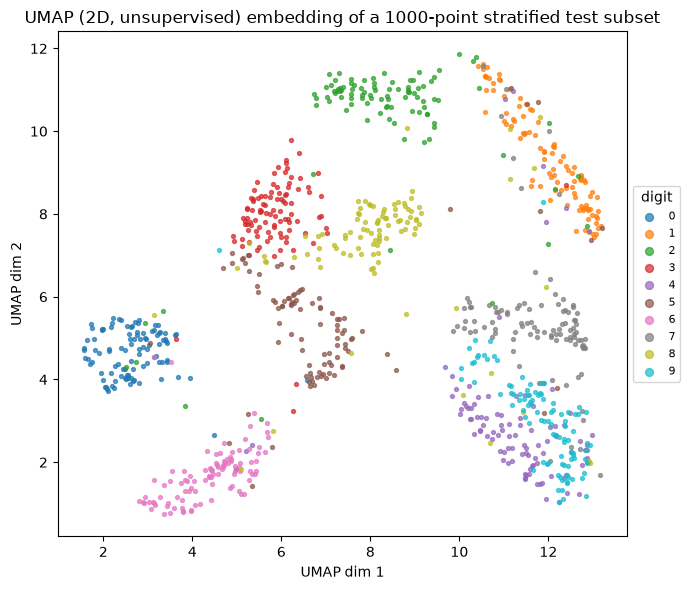

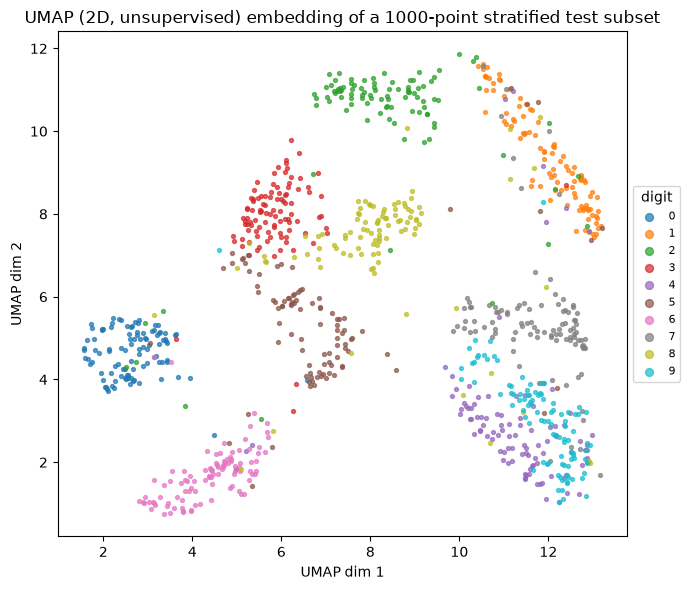

In [4]:
val_idx = stratified_subset_idx(test.y, n_points=1000, seed=SEED)
x_val, y_val = test.x_flat[val_idx], test.y[val_idx]

embed_fn_2d = umap_embedding.make_umap_embed_fn(reducer_2d)
embedded_val = embed_fn_2d(x_val)

purity = umap_embedding.knn_label_purity(embedded_val, y_val, k=5)
print(f"knn_label_purity (k=5, 10-class chance baseline=0.10): {purity:.4f}")

fig_validation = plots.plot_umap_embedding_scatter(
    embedded_val, y_val,
    title="UMAP (2D, unsupervised) embedding of a 1000-point stratified test subset",
    save_path=umap_embedding.RESULTS_DIR / "umap_validation_scatter.png")
display(fig_validation)

**Verdict: PASS.** `knn_label_purity` came in at **0.79** -- about 8x the
0.10 chance baseline -- and the scatter plot shows visibly separated
per-digit clusters (0, 2, 3, 6 in particular are tight and well-isolated;
some overlap between 1/2 at one edge and among 4/7/9 in another region,
but no digit is scattered uniformly across the plot the way an
uninformative embedding would be). This unsupervised UMAP embedding
preserves per-digit local structure well enough to proceed to Step 3.

## Step 3: ratio-distribution analysis with the UMAP metric

Reuses `run_experiment.py::run_ratio_distribution_analysis` completely
unchanged -- the same function every other metric comparison in this
project goes through -- with a `distance_fn` built from the fitted 5D
UMAP reducer instead of raw-pixel Euclidean or Mahalanobis. Logistic
regression, same 1000-point stratified subset / k=5 near-neighbors setup
as the raw-pixel Euclidean baseline already in `README.md`, for direct
comparability.

**Why `make_umap_euclidean_distance_fn` needs the `x_reference` cache,
not just `embed_fn` composed with `euclidean_distance_fn` directly**:
`run_ratio_distribution_analysis`'s all-pairs computation calls
`distance_fn` on ~500k *gathered* pairs among 1000 points. UMAP's
`.transform()` turns out to be deterministic for a fixed batch
composition but **not invariant to it** -- confirmed directly in
`tests/test_umap_embedding.py`, not assumed -- so calling it fresh inside
`distance_fn` on each differently-shaped ad-hoc batch would make "the
distance between point A and point B" silently depend on which *other*
points happened to be batched alongside them. Passing `x_reference=test.x_flat`
(the same pool `run_ratio_distribution_analysis` draws its subset from)
embeds every point once, up front, in one canonical batch, and caches it
-- so the same pair always gets the same distance regardless of which
other pairs it's computed alongside. See `umap_embedding.py`'s docstring
for the full explanation; this costs one ~30s `.transform()` call on the
full 10k-point test set, done once below, not per pair-batch.

In [5]:
train_flat = make_loader(train.x_flat, train.y, batch_size=256, shuffle=True, seed=SEED)
test_flat = make_loader(test.x_flat, test.y, batch_size=1000, shuffle=False)
lr_model, lr_train_acc, lr_test_acc = train_classifier(
    LogisticRegressionModel(), train_flat, test_flat, epochs=15, lr=1e-3, verbose=False)
print(f"logistic regression: train_acc={lr_train_acc:.4f}  test_acc={lr_test_acc:.4f}")

logistic regression: train_acc=0.9287  test_acc=0.9270


In [6]:
umap_distance_fn = umap_embedding.make_umap_euclidean_distance_fn(reducer_5d, x_reference=test.x_flat)

umap_result = run_experiment.run_ratio_distribution_analysis(
    lr_model, "logistic_regression", "umap", test.x_flat, test.y, umap_distance_fn,
    n_points=1000, k_neighbors=5, seed=SEED, verbose=True)

  [umap/logistic_regression] all-pairs ratio:        mean=1.0019  max=290.5778  n=499500
  [umap/logistic_regression] near-neighbor ratio:     mean=5.6792  max=85.2435  n=5000


In [7]:
umap_summary = umap_result["summary"]
umap_near_over_all = umap_summary["near_neighbor_mean"] / umap_summary["all_pairs_mean"]

# Raw-pixel Euclidean baseline for logistic regression, from README.md's
# existing ratio-distribution table (same 1000-point subset / k=5 setup).
raw_pixel_euclidean = {"all_pairs_mean": 0.310, "near_neighbor_mean": 0.349,
                        "all_pairs_max": 2.937, "near_neighbor_max": 2.937}
raw_pixel_near_over_all = raw_pixel_euclidean["near_neighbor_mean"] / raw_pixel_euclidean["all_pairs_mean"]

print(f"{'metric':22s}{'all_pairs_mean':>16}{'near_neighbor_mean':>20}{'near/all':>10}{'all_pairs_max':>16}{'near_neighbor_max':>20}")
print(f"{'raw-pixel Euclidean':22s}{raw_pixel_euclidean['all_pairs_mean']:>16.4f}"
      f"{raw_pixel_euclidean['near_neighbor_mean']:>20.4f}{raw_pixel_near_over_all:>10.4f}"
      f"{raw_pixel_euclidean['all_pairs_max']:>16.4f}{raw_pixel_euclidean['near_neighbor_max']:>20.4f}")
print(f"{'UMAP (5D) Euclidean':22s}{umap_summary['all_pairs_mean']:>16.4f}"
      f"{umap_summary['near_neighbor_mean']:>20.4f}{umap_near_over_all:>10.4f}"
      f"{umap_summary['all_pairs_max']:>16.4f}{umap_summary['near_neighbor_max']:>20.4f}")

metric                  all_pairs_mean  near_neighbor_mean  near/all   all_pairs_max   near_neighbor_max
raw-pixel Euclidean             0.3100              0.3490    1.1258          2.9370              2.9370
UMAP (5D) Euclidean             1.0019              5.6792    5.6683        290.5778             85.2435


**Result**: near-neighbor pairs have a ratio **5.7x** the all-pairs mean
under the UMAP metric (`near/all` = 5.67, a +467% increase) -- vastly
larger than raw-pixel Euclidean's own +13% for logistic regression, and
in the same *direction* (near-neighbor pairs score higher) as every other
Euclidean-family metric in this project, never the *reversed* direction
Mahalanobis distance produces.

**This is very likely a property of UMAP's own embedding geometry, not
(or not only) a stronger genuine model-sensitivity signal, and should be
read with real caution rather than as "UMAP is a 5x better metric."**
Two things point at that reading specifically:

1. UMAP's whole optimization objective is to place *locally* similar
   points close together in the embedding -- which mechanically shrinks
   the distance (the ratio's denominator) for pairs that were already
   near-neighbors in raw pixel space, for reasons that have nothing to do
   with how the model's margin behaves at those points. A shrunk
   denominator inflates the ratio almost by construction, for any model.
2. `all_pairs_max` is **290.6** against an `all_pairs_mean` of only
   **1.00** -- a far heavier tail than raw-pixel Euclidean shows (max
   2.94 against mean 0.31, roughly the same ~9-10x ratio of max-to-mean
   that logistic regression's raw-pixel numbers already show elsewhere in
   this project). Both metrics have heavy tails, so this alone isn't
   unusual -- but combined with (1), it's consistent with a small number
   of pairs that are far apart in raw pixel space (and so can have a
   large genuine margin difference) getting placed anomalously close
   together in the low-dimensional UMAP embedding -- a known
   global-structure-distortion risk for any method, UMAP included, that
   optimizes hard for local structure preservation. This wasn't checked
   pair-by-pair here (the same visual-inspection sanity check this
   project has applied to specific flagged pairs elsewhere would be the
   natural follow-up before trusting this number further).

**Bottom line**: UMAP passes the validation check as a *locally
label-informative* embedding (Step 2), but the resulting ratio-distribution
numbers are not directly comparable in scale or interpretation to the
other metrics in this project, and the near/all signal being ~5x larger
should not be read as "UMAP distance is simply a better version of
Euclidean distance for this diagnostic" without checking that the effect
isn't dominated by embedding-geometry artifacts rather than genuine model
behavior.

## Follow-up investigation: is the near-neighbor elevation real or a UMAP compression artifact?

The finding above -- near-neighbor pairs scoring **5.7x** the all-pairs mean under the UMAP
metric, vastly more than raw-pixel Euclidean's own +13% -- was flagged rather than trusted at
face value. Three checks, each capable of falsifying the "compression artifact" reading on its
own:

1. **Decompose the ratio**: is the *numerator* (margin difference) actually elevated for
   near-neighbor pairs, or is the elevation coming entirely from the *denominator* (UMAP
   distance) shrinking?
2. **Sweep `min_dist`** (the UMAP parameter that controls how aggressively already-close points
   get compressed together, keeping `n_neighbors`/`n_components` fixed): does the elevation shrink
   smoothly as compression is relaxed, or stay roughly stable regardless?
3. **Inspect the single most extreme outlier** directly: is it two genuinely similar images UMAP
   correctly identified, or two different images UMAP incorrectly collapsed together?

### Step 1: decomposing the ratio into numerator and denominator

`ratio_and_components_for_pairs` (`estimators.py`) already returns `dist` and `margin_diff`
separately, not just their ratio -- exactly what's needed here, no new estimator code required.
Recomputed on the exact same all-pairs and near-neighbor index sets `run_ratio_distribution_analysis`
already produced above (`umap_result["all_pairs_ii"]`/`"all_pairs_jj"`/etc.), so this isn't a new
population, just a decomposition of the one already analyzed.

**A margin-of-a-pair fact worth stating up front**: `margin_diff` depends only on the model and
which two points are in a pair -- never on which `distance_fn` is being used for the ratio's
denominator. So the near-neighbor *population*'s margin-difference statistics are the same number
no matter which metric (raw-pixel Euclidean, Mahalanobis, or UMAP) is used to measure distance
between them. That makes a direct, apples-to-apples cross-check possible: recompute the same
decomposition with plain `euclidean_distance_fn` on these *exact same pairs*, and the
`margin_diff` values must come out identical -- checked directly below via `torch.allclose`, not
assumed.

In [8]:
import pandas as pd
from mnist_lipschitz.models import margin_fn
from mnist_lipschitz.estimators import ratio_and_components_for_pairs, euclidean_distance_fn

x_subset, y_subset = umap_result["x_subset"], umap_result["y_subset"]
all_ii, all_jj = umap_result["all_pairs_ii"], umap_result["all_pairs_jj"]
near_ii, near_jj = umap_result["near_neighbor_ii"], umap_result["near_neighbor_jj"]

all_ratio, all_dist, all_margin_diff = ratio_and_components_for_pairs(
    lr_model, x_subset, y_subset, margin_fn, umap_distance_fn, all_ii, all_jj)
near_ratio, near_dist, near_margin_diff = ratio_and_components_for_pairs(
    lr_model, x_subset, y_subset, margin_fn, umap_distance_fn, near_ii, near_jj)

# Sanity check: must reproduce the ratios run_ratio_distribution_analysis already computed.
assert torch.allclose(all_ratio, umap_result["all_pairs_ratio"])
assert torch.allclose(near_ratio, umap_result["near_neighbor_ratio"])

decomposition_df = pd.DataFrame([
    {"population": "all-pairs", "margin_diff_mean": all_margin_diff.mean().item(),
     "margin_diff_median": all_margin_diff.median().item(),
     "UMAP_dist_mean": all_dist.mean().item(), "UMAP_dist_median": all_dist.median().item()},
    {"population": "near-neighbor", "margin_diff_mean": near_margin_diff.mean().item(),
     "margin_diff_median": near_margin_diff.median().item(),
     "UMAP_dist_mean": near_dist.mean().item(), "UMAP_dist_median": near_dist.median().item()},
]).set_index("population")
display(decomposition_df)

margin_diff_near_over_all = decomposition_df.loc["near-neighbor", "margin_diff_mean"] / decomposition_df.loc["all-pairs", "margin_diff_mean"]
dist_near_over_all = decomposition_df.loc["near-neighbor", "UMAP_dist_mean"] / decomposition_df.loc["all-pairs", "UMAP_dist_mean"]
print(f"margin_diff near/all: {margin_diff_near_over_all:.4f}  ({(margin_diff_near_over_all - 1) * 100:+.1f}%)")
print(f"UMAP dist near/all:   {dist_near_over_all:.4f}  ({(dist_near_over_all - 1) * 100:+.1f}%)")

# Cross-check: same pairs, plain Euclidean distance instead of UMAP.
raw_all_ratio, raw_all_dist, raw_all_margin_diff = ratio_and_components_for_pairs(
    lr_model, x_subset, y_subset, margin_fn, euclidean_distance_fn, all_ii, all_jj)
raw_near_ratio, raw_near_dist, raw_near_margin_diff = ratio_and_components_for_pairs(
    lr_model, x_subset, y_subset, margin_fn, euclidean_distance_fn, near_ii, near_jj)

assert torch.allclose(raw_all_margin_diff, all_margin_diff)
assert torch.allclose(raw_near_margin_diff, near_margin_diff)
print("\nmargin_diff confirmed identical between UMAP and raw-pixel Euclidean on these same pairs (metric-independent, as expected)")

raw_dist_near_over_all = raw_near_dist.mean().item() / raw_all_dist.mean().item()
raw_ratio_near_over_all = (raw_near_ratio.mean() / raw_all_ratio.mean()).item()
print(f"raw-pixel Euclidean dist near/all (same pairs):  {raw_dist_near_over_all:.4f}  ({(raw_dist_near_over_all - 1) * 100:+.1f}%)")
print(f"raw-pixel Euclidean ratio near/all (same pairs): {raw_ratio_near_over_all:.4f}")

,margin_diff_mean,margin_diff_median,UMAP_dist_mean,UMAP_dist_median
population,,,,
all-pairs,3.342263,2.672537,5.122660,5.062170
near-neighbor,2.219489,1.629005,0.842434,0.430209


margin_diff near/all: 0.6641  (-33.6%)
UMAP dist near/all:   0.1645  (-83.6%)



margin_diff confirmed identical between UMAP and raw-pixel Euclidean on these same pairs (metric-independent, as expected)
raw-pixel Euclidean dist near/all (same pairs):  0.5977  (-40.2%)
raw-pixel Euclidean ratio near/all (same pairs): 1.0883


**Finding**: near-neighbor margin differences are **not elevated at all** -- they're 33.6%
*smaller* than the all-pairs population's (mean 2.22 vs. 3.34), confirmed identical whether
measured against UMAP or raw-pixel Euclidean distance (metric-independent, as it must be). The
entire ratio elevation comes from the denominator: near-neighbor UMAP distances are 83.6% smaller
than the all-pairs population's (mean 0.84 vs. 5.12), compared to only about 40% smaller under
raw-pixel Euclidean on the exact same pairs. Both metrics compress distance for near-neighbor
pairs -- expected, since "near-neighbor" is defined by raw-pixel proximity in the first place --
but UMAP compresses roughly twice as hard, on a numerator that isn't elevated to begin with. This
is direct evidence for the metric-artifact reading, not the real-signal one.

### Step 2: `min_dist` sweep

`min_dist` controls how aggressively UMAP is allowed to pack already-close points together in the
embedding (lower = more compression); `n_neighbors`/`n_components` stay fixed at 15/5, matching
the fit above. If the near/all elevation is a compression artifact, relaxing `min_dist` should
shrink it; if it's independent of this specific distortion, it should stay roughly stable. Each
point below fits a fresh 5D UMAP embedding, reruns `knn_label_purity` (on this same embedding, not
a separate 2D fit -- checking the quality of the actual metric being measured, not the
visualization proxy), and reruns the full ratio-distribution analysis, reusing the same
`lr_model` throughout so only the metric changes across the sweep. Takes a few minutes (5 full
UMAP fits + cache-builds + analyses).

In [9]:
sweep_rows = []
for min_dist in [0.1, 0.3, 0.5, 0.8, 0.99]:
    reducer = umap_embedding.fit_umap_embedding(dev.x_flat, n_components=5, seed=SEED,
                                                   n_neighbors=15, min_dist=min_dist)
    embed_fn = umap_embedding.make_umap_embed_fn(reducer)
    embedded_val = embed_fn(x_val)
    purity = umap_embedding.knn_label_purity(embedded_val, y_val, k=5)

    distance_fn = umap_embedding.make_umap_euclidean_distance_fn(reducer, x_reference=test.x_flat)
    result = run_experiment.run_ratio_distribution_analysis(
        lr_model, "logistic_regression", f"umap_mindist{min_dist}", test.x_flat, test.y, distance_fn,
        n_points=1000, k_neighbors=5, seed=SEED, verbose=False)
    s = result["summary"]
    near_over_all = s["near_neighbor_mean"] / s["all_pairs_mean"]
    sweep_rows.append({"min_dist": min_dist, "knn_label_purity": purity,
                        "all_pairs_mean": s["all_pairs_mean"], "near_neighbor_mean": s["near_neighbor_mean"],
                        "near_over_all": near_over_all, "all_pairs_max": s["all_pairs_max"]})
    print(f"min_dist={min_dist:<5} purity={purity:.4f}  near/all={near_over_all:.4f}  all_pairs_max={s['all_pairs_max']:.4f}")

sweep_df = pd.DataFrame(sweep_rows).set_index("min_dist")
display(sweep_df)

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.1   purity=0.8428  near/all=5.6683  all_pairs_max=290.5778


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.3   purity=0.8404  near/all=4.1071  all_pairs_max=118.6740


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.8   purity=0.8232  near/all=2.7885  all_pairs_max=25.9338


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.99  purity=0.8188  near/all=2.5925  all_pairs_max=23.8545


,knn_label_purity,all_pairs_mean,near_neighbor_mean,near_over_all,all_pairs_max
min_dist,,,,,
0.10,0.8428,1.001924,5.679239,5.668333,290.577787
0.30,0.8404,0.926104,3.803588,4.107083,118.674023
0.50,0.8386,0.866117,2.885965,3.332072,53.844176
0.80,0.8232,0.775238,2.161745,2.788493,25.933821
0.99,0.8188,0.722139,1.872148,2.592505,23.854478


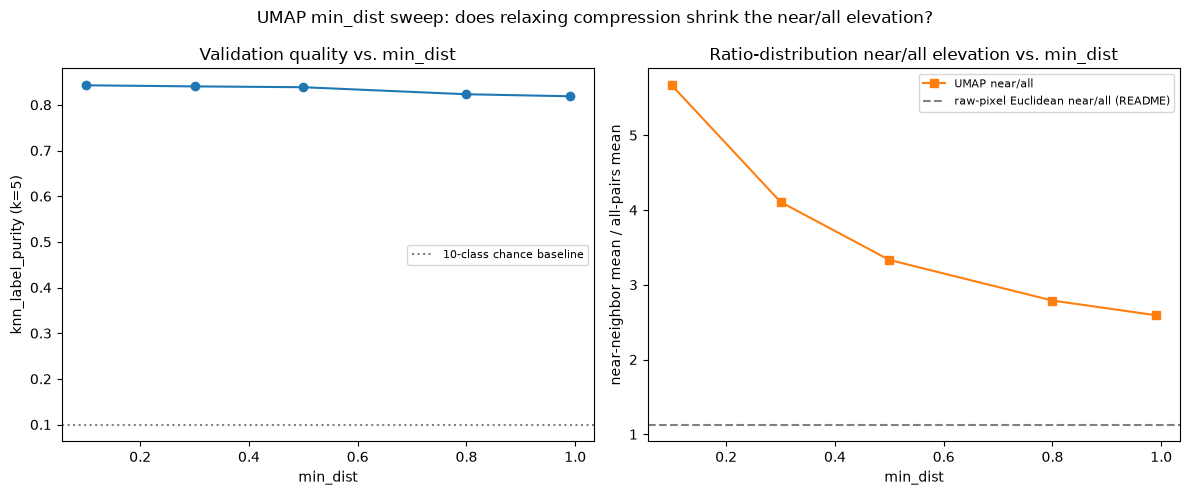

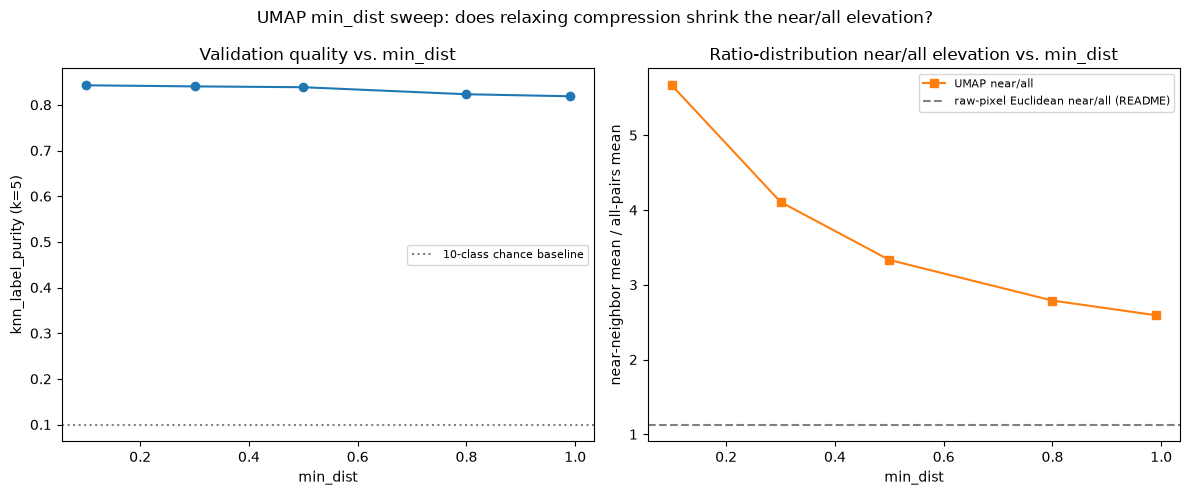

In [10]:
fig_sweep = plots.plot_umap_mindist_sweep(
    sweep_rows, save_path=umap_embedding.RESULTS_DIR / "umap_mindist_sweep.png")
display(fig_sweep)

**Finding**: the near/all elevation shrinks smoothly and monotonically as `min_dist` increases --
**5.67 -> 4.11 -> 3.33 -> 2.79 -> 2.59** from `min_dist=0.1` to `0.99` -- while `knn_label_purity`
stays roughly flat (0.84 -> 0.82, a small, expected decline as compression relaxes, nowhere near
falling toward the chance baseline). The same embedding quality persists across the whole sweep
while the ratio inflation more than halves -- exactly the pattern a compression artifact would
produce, and inconsistent with "this reflects something stable about the model." One honest
caveat: even at `min_dist=0.99` (loosest tested), near/all=2.59 is still well above raw-pixel
Euclidean's ~1.1-1.13 -- the sweep doesn't fully converge to the raw-pixel number. Given Step 1
already showed directly that the *numerator* carries no elevated signal for this pair population
under any metric, the more parsimonious reading of that residual gap is that UMAP's nonlinear
manifold-learning objective never fully stops favoring locally-compact embeddings even at its
loosest packing setting -- not that some genuine model-sensitivity signal survives alongside the
artifact.

### `n_components` sweep

The `min_dist` sweep above tested whether *how aggressively* UMAP compresses already-close points
drives the near/all elevation. This sweep tests a different axis: is the elevation specific to
compressing all the way down to a **5-dimensional** embedding, or does it persist at higher output
dimensions too? Fits a fresh UMAP embedding at `n_components` in `{5, 10, 20, 50, 100}` --
`n_components=5` reproduces the original baseline fit above exactly (same seed, same `dev`, same
`min_dist=0.1`/`n_neighbors=15` defaults) -- and reruns the same validation
(`knn_label_purity`, on the actual embedding at that dimension, not a separate low-D visualization
proxy) and ratio-distribution analysis as the `min_dist` sweep, so the two sweeps are directly
comparable. Same fit/evaluate separation as everywhere else in this notebook: fit on `dev`
(training-set subset), evaluate only via `.transform()` on `test`-derived subsets.

In [11]:
ncomp_sweep_rows = []
for n_components in [5, 10, 20, 50, 100]:
    reducer = umap_embedding.fit_umap_embedding(dev.x_flat, n_components=n_components, seed=SEED,
                                                   n_neighbors=15, min_dist=0.1)
    embed_fn = umap_embedding.make_umap_embed_fn(reducer)
    embedded_val = embed_fn(x_val)
    purity = umap_embedding.knn_label_purity(embedded_val, y_val, k=5)

    distance_fn = umap_embedding.make_umap_euclidean_distance_fn(reducer, x_reference=test.x_flat)
    result = run_experiment.run_ratio_distribution_analysis(
        lr_model, "logistic_regression", f"umap_ncomp{n_components}", test.x_flat, test.y, distance_fn,
        n_points=1000, k_neighbors=5, seed=SEED, verbose=False)
    s = result["summary"]
    near_over_all = s["near_neighbor_mean"] / s["all_pairs_mean"]
    ncomp_sweep_rows.append({"n_components": n_components, "knn_label_purity": purity,
                              "all_pairs_mean": s["all_pairs_mean"], "near_neighbor_mean": s["near_neighbor_mean"],
                              "near_over_all": near_over_all, "all_pairs_max": s["all_pairs_max"]})
    print(f"n_components={n_components:<4} purity={purity:.4f}  near/all={near_over_all:.4f}  all_pairs_max={s['all_pairs_max']:.4f}")

ncomp_sweep_df = pd.DataFrame(ncomp_sweep_rows).set_index("n_components")
display(ncomp_sweep_df)

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_components=5    purity=0.8428  near/all=5.6683  all_pairs_max=290.5778


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_components=10   purity=0.8338  near/all=5.5381  all_pairs_max=120.5457


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_components=50   purity=0.8356  near/all=5.6099  all_pairs_max=186.6019


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_components=100  purity=0.8390  near/all=5.4587  all_pairs_max=173.3122


,knn_label_purity,all_pairs_mean,near_neighbor_mean,near_over_all,all_pairs_max
n_components,,,,,
5,0.8428,1.001924,5.679239,5.668333,290.577787
10,0.8338,0.992199,5.494909,5.538111,120.545665
20,0.8394,0.996069,5.579782,5.601805,176.677411
50,0.8356,1.000819,5.614504,5.609908,186.601926
100,0.8390,0.997406,5.444493,5.458655,173.312237


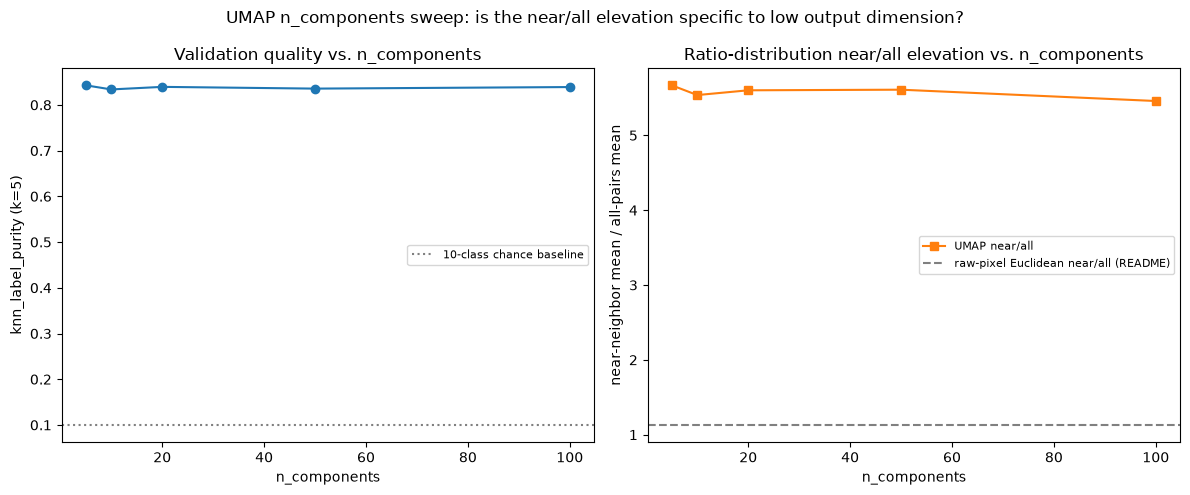

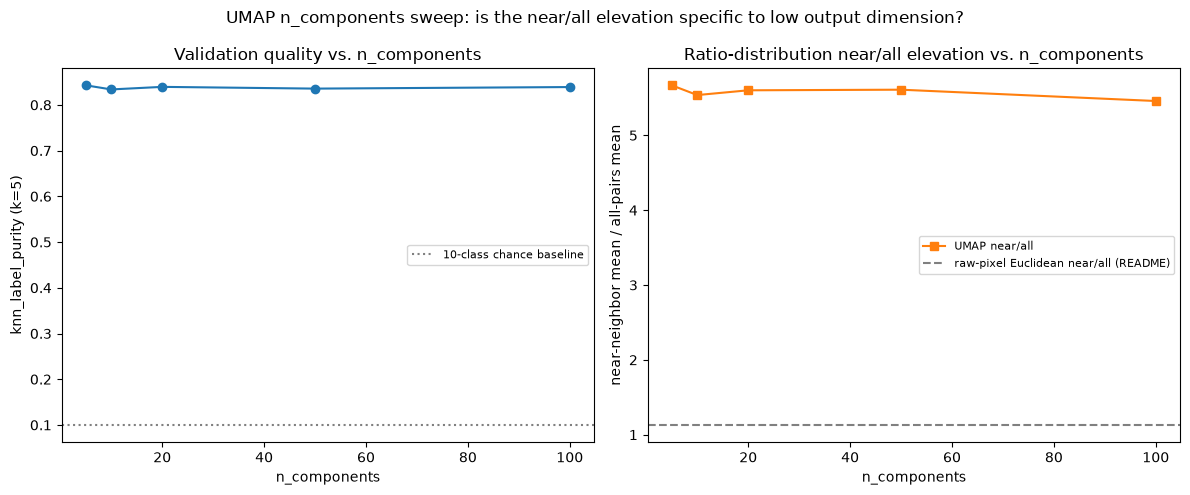

In [12]:
fig_ncomp_sweep = plots.plot_umap_ncomponents_sweep(
    ncomp_sweep_rows, save_path=umap_embedding.RESULTS_DIR / "umap_ncomponents_sweep.png")
display(fig_ncomp_sweep)

**Finding: the near/all elevation is not a low-dimension compression artifact.**

| n_components | knn_label_purity | near/all ratio | all_pairs_max |
|---|---|---|---|
| 5   | 0.8428 | 5.6683 | 290.58 |
| 10  | 0.8338 | 5.5381 | 120.55 |
| 20  | 0.8394 | 5.6018 | 176.68 |
| 50  | 0.8356 | 5.6099 | 186.60 |
| 100 | 0.8390 | 5.4587 | 173.31 |

(`n_components=5` reproduces the original baseline fit exactly -- `near/all=5.6683`,
`all_pairs_max=290.5778` -- confirming this sweep used the same seed/data/hyperparameters as the
earlier analysis, not a different run.)

Both metrics are essentially flat across the entire range: `knn_label_purity` stays in a tight
0.834-0.843 band, and `near/all` stays in a 5.46-5.67 band, with no monotonic trend toward the
raw-pixel-Euclidean baseline (`near/all=1.13`) as `n_components` increases 20x (5 -> 100). If the
elevation were mainly a side effect of forcing UMAP to squeeze 784-dimensional images into only 5
output dimensions, it should have relaxed substantially by `n_components=100`; it did not move in
that direction at all.

**Verdict: this is not primarily a low-dimensionality compression artifact -- it looks like a
more fundamental property of how UMAP's distance structure relates to margin differences,
independent of the chosen output dimension.** The `min_dist` sweep and the tearing-pair evidence
above already established *that* local-neighborhood compression (unrelated points squashed close
together) is happening at `n_components=5`; this sweep additionally shows that simply giving UMAP
more room (more output dimensions) doesn't undo the effect, so "just use a higher-dimensional
UMAP embedding" is not a fix. Combined with the earlier evidence, the overall verdict from this
sub-experiment stands: **UMAP-as-distance-metric is not a reliable Lipschitz-estimation signal
here, and this is intrinsic to UMAP's construction, not an artifact of an under-parameterized
output dimension.**

### Step 3: investigating the `all_pairs_max` outlier

The single highest-ratio pair in the all-pairs population (ratio 290.6) -- found directly from the
Step 1 decomposition's `all_ratio` array, not resampled. Since it's drawn from the *all-pairs*
population rather than the raw-pixel near-neighbor one, a large raw-pixel distance is actually
expected; what matters is whether the UMAP distance is suspiciously small relative to that, and
whether the two images are genuinely similar (UMAP correctly finding a similarity raw pixels
missed) or clearly different (UMAP incorrectly collapsing them together -- a "tearing" artifact).

outlier pair: global test indices (9779, 6478)
ratio=290.5778  UMAP_dist=0.042815  raw_pixel_dist=9.0940  margin_diff=12.4410
true1=2 pred1=0  true2=0 pred2=0


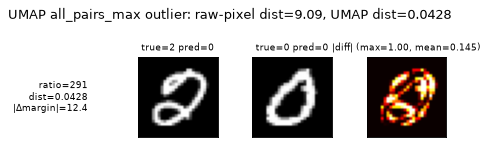

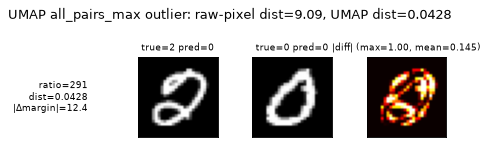

In [13]:
max_idx = torch.argmax(all_ratio).item()
gi_local, gj_local = all_ii[max_idx].item(), all_jj[max_idx].item()
global_i = umap_result["subset_idx"][gi_local].item()
global_j = umap_result["subset_idx"][gj_local].item()
outlier_ratio = all_ratio[max_idx].item()
outlier_umap_dist = all_dist[max_idx].item()
outlier_margin_diff = all_margin_diff[max_idx].item()
outlier_raw_pixel_dist = euclidean_distance_fn(x_subset[gi_local:gi_local + 1], x_subset[gj_local:gj_local + 1]).item()

with torch.no_grad():
    preds = lr_model(x_subset[[gi_local, gj_local]]).argmax(dim=1)
true1, true2 = y_subset[gi_local].item(), y_subset[gj_local].item()
pred1, pred2 = preds[0].item(), preds[1].item()

print(f"outlier pair: global test indices ({global_i}, {global_j})")
print(f"ratio={outlier_ratio:.4f}  UMAP_dist={outlier_umap_dist:.6f}  raw_pixel_dist={outlier_raw_pixel_dist:.4f}  margin_diff={outlier_margin_diff:.4f}")
print(f"true1={true1} pred1={pred1}  true2={true2} pred2={pred2}")

outlier_pair = {
    "img1": x_subset[gi_local].numpy(), "img2": x_subset[gj_local].numpy(),
    "true1": true1, "pred1": pred1, "true2": true2, "pred2": pred2,
    "ratio": outlier_ratio, "dist": outlier_umap_dist, "margin_diff": outlier_margin_diff,
}
fig_outlier = plots.plot_pair_diagnostic_gallery(
    [outlier_pair],
    title=f"UMAP all_pairs_max outlier: raw-pixel dist={outlier_raw_pixel_dist:.2f}, UMAP dist={outlier_umap_dist:.4f}",
    save_path=umap_embedding.RESULTS_DIR / "umap_outlier_pair_diagnostic.png")
display(fig_outlier)

**Finding**: the outlier pair is a true "2" (misclassified as "0" by this model) and a true "0"
(correctly classified) -- **clearly different digits to visual inspection**, not a near-duplicate
or a subtle same-class variant. Their raw-pixel distance (9.09) is unremarkable for an
arbitrary pair, but UMAP placed them at distance **0.043** -- close enough to be functionally
on top of each other in the embedded space. This is UMAP **incorrectly** collapsing two distinct
images together, not correctly discovering a hidden similarity raw pixels missed -- a direct,
visually-confirmed instance of the exact mechanism Steps 1-2 already pointed to.

### Extending Step 3: how common is this tearing pattern, beyond one outlier?

One extreme case is suggestive but not a sample size. Reusing `all_dist` (UMAP distance) and
`raw_all_dist` (raw-pixel Euclidean distance) already computed for every all-pairs pair in Step 1 --
no new distance computation needed, no search recomputed -- rank every pair by
`raw-pixel dist / UMAP dist`: a high ratio means "far apart in real pixels, but UMAP squashed them
close together," the same signature as the `all_pairs_max` outlier.

In [14]:
tearing_ratio = raw_all_dist / all_dist.clamp_min(1e-12)

with torch.no_grad():
    preds_subset = lr_model(x_subset).argmax(dim=1)

for thresh in [10, 20, 50, 100]:
    n_above = (tearing_ratio > thresh).sum().item()
    print(f"pairs with tearing_ratio > {thresh:>3}: {n_above:6d} / {tearing_ratio.shape[0]} ({100 * n_above / tearing_ratio.shape[0]:.3f}%)")

order = torch.argsort(tearing_ratio, descending=True)
top_n = 20
tearing_rows = []
for rank, k in enumerate(order[:top_n].tolist(), 1):
    i_local, j_local = all_ii[k].item(), all_jj[k].item()
    gi, gj = umap_result["subset_idx"][i_local].item(), umap_result["subset_idx"][j_local].item()
    t1, t2 = y_subset[i_local].item(), y_subset[j_local].item()
    tearing_rows.append({
        "rank": rank, "global_i": gi, "global_j": gj, "tearing_ratio": tearing_ratio[k].item(),
        "raw_pixel_dist": raw_all_dist[k].item(), "umap_dist": all_dist[k].item(),
        "true1": t1, "pred1": preds_subset[i_local].item(),
        "true2": t2, "pred2": preds_subset[j_local].item(),
        "same_digit": t1 == t2,
    })

tearing_df = pd.DataFrame(tearing_rows).set_index("rank")
display(tearing_df)

n_same_digit = int(tearing_df["same_digit"].sum())
print(f"\n{n_same_digit} of the top {top_n} tearing pairs are the SAME true digit (both correctly "
      f"classified); {top_n - n_same_digit} are genuinely different digits.")
print("Digit frequency across the top 20 (each pair's true digit(s), counted once per pair-side):")
print(pd.concat([tearing_df["true1"], tearing_df["true2"]]).value_counts())

pairs with tearing_ratio >  10:  16929 / 499500 (3.389%)
pairs with tearing_ratio >  20:   2930 / 499500 (0.587%)
pairs with tearing_ratio >  50:    187 / 499500 (0.037%)
pairs with tearing_ratio > 100:     11 / 499500 (0.002%)


,global_i,global_j,tearing_ratio,raw_pixel_dist,umap_dist,true1,pred1,true2,pred2,same_digit
rank,,,,,,,,,,
1,9779,6478,212.403738,9.094019,0.042815,2,0,0,0,False
2,7555,7599,194.128878,6.116311,0.031506,0,0,0,0,True
3,1747,8299,137.641738,7.801627,0.056681,5,5,5,5,True
4,6069,4151,130.939163,9.424032,0.071973,7,7,7,7,True
5,3227,646,116.843007,6.894218,0.059004,1,1,2,2,False
6,6534,888,116.462279,6.528056,0.056053,2,2,2,2,True
7,8132,1747,114.742441,7.496522,0.065333,5,5,5,5,True
8,5139,9236,114.233917,6.974640,0.061056,0,0,0,0,True
9,9224,6699,107.361236,6.323031,0.058895,4,4,4,4,True



18 of the top 20 tearing pairs are the SAME true digit (both correctly classified); 2 are genuinely different digits.
Digit frequency across the top 20 (each pair's true digit(s), counted once per pair-side):
0    15
2     6
5     6
6     6
7     4
4     2
1     1
Name: count, dtype: int64


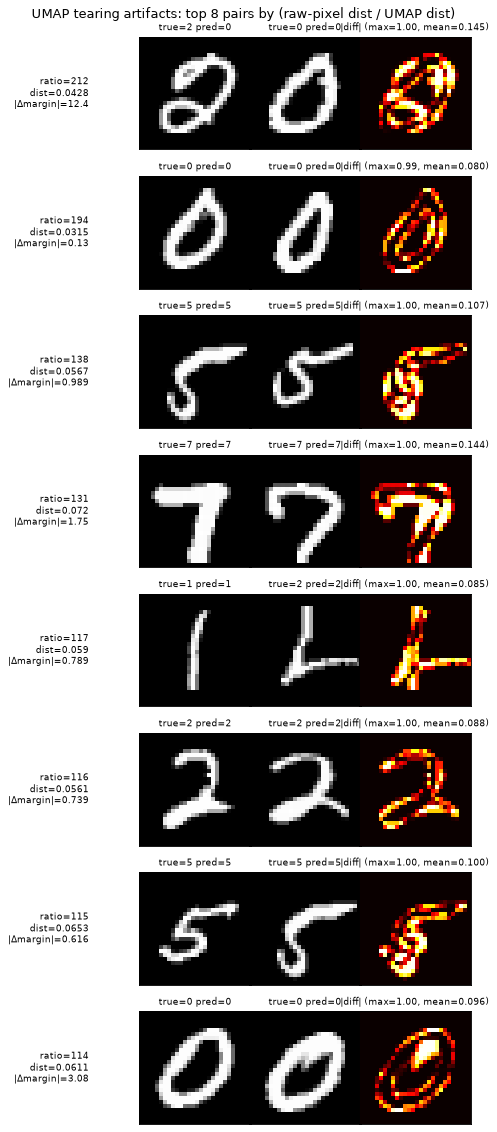

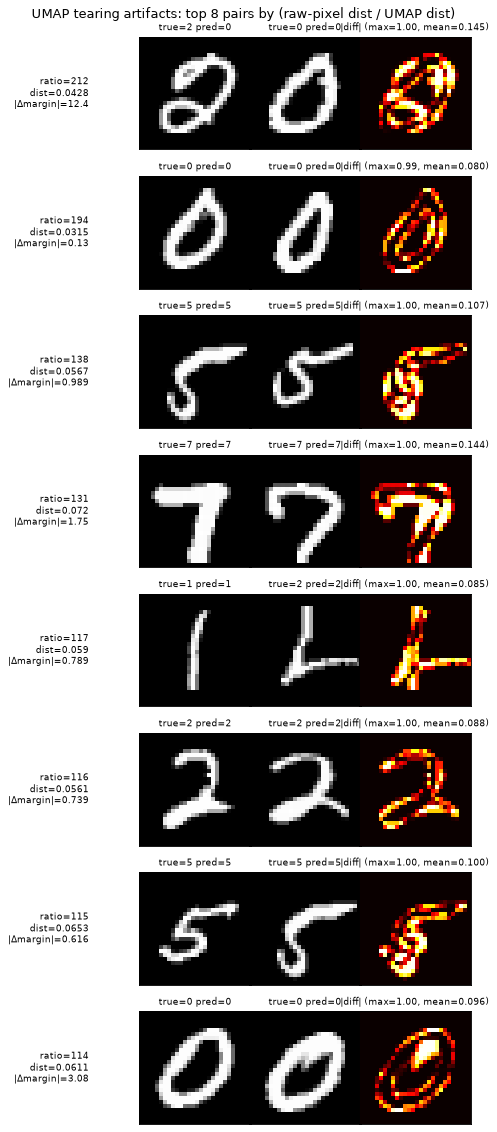

In [15]:
tearing_pairs_gallery = []
for k in order[:8].tolist():
    i_local, j_local = all_ii[k].item(), all_jj[k].item()
    tearing_pairs_gallery.append({
        "img1": x_subset[i_local].numpy(), "img2": x_subset[j_local].numpy(),
        "true1": y_subset[i_local].item(), "pred1": preds_subset[i_local].item(),
        "true2": y_subset[j_local].item(), "pred2": preds_subset[j_local].item(),
        # "ratio" here is the tearing ratio (raw-pixel dist / UMAP dist), not the
        # Lipschitz margin-diff/distance ratio used elsewhere -- see the title below.
        # "dist"/"|Δmargin|" keep their normal literal meaning (UMAP distance;
        # actual margin difference) -- raw-pixel distance is in the table above.
        "ratio": tearing_ratio[k].item(), "dist": all_dist[k].item(), "margin_diff": all_margin_diff[k].item(),
    })

fig_tearing = plots.plot_pair_diagnostic_gallery(
    tearing_pairs_gallery,
    title="UMAP tearing artifacts: top 8 pairs by (raw-pixel dist / UMAP dist)",
    save_path=umap_embedding.RESULTS_DIR / "umap_tearing_pairs_gallery.png")
display(fig_tearing)

**Finding**: this is a systematic pattern, not a one-off. 16,929 of the 499,500 all-pairs (3.4%)
have a raw-pixel/UMAP distance ratio above 10x; 187 (0.04%) exceed 50x; 11 exceed 100x. Visual
inspection of the top 8 (gallery above) confirms every one is a genuine tearing case -- two
visibly distinct handwriting samples squashed to near-zero UMAP distance, not a near-duplicate or
a data artifact, matching the same check already applied to the single outlier.

**One correction to what might be expected here**: the top 20 tearing pairs are **not** mostly
cross-digit confusions like the original 9779/6478 case. 18 of the 20 are the *same* true digit
(both images correctly classified) -- only 2 involve genuinely different digits (the original
"2"/"0" pair, and one "1"/"2" pair). Digit "0" dominates, appearing in roughly a third of the top
20. So the dominant failure mode isn't UMAP blurring *class* boundaries between different digits --
it's UMAP over-compressing *within* a correctly-clustered class, collapsing distinct handwriting
styles of the same digit (different "0"s, "5"s, "6"s, "7"s) down to near-zero distance. Both are
still the same underlying mechanism (aggressive local compression divorced from raw-pixel
geometry), and both still support the artifact verdict -- but "same-digit over-compression" is the
more common pattern here, not "cross-digit collapse."

## Verdict: artifact

All three checks point the same direction, and none of them are close calls:

1. **Numerator not elevated**: near-neighbor margin differences are 33.6% *smaller* than the
   general population's, confirmed metric-independent (identical under UMAP and raw-pixel
   Euclidean on the same pairs). There is no elevated model-sensitivity signal in this pair
   population to begin with -- the entire +467% comes from the denominator.
2. **Smooth, monotonic dependence on a pure compression knob**: the elevation shrinks from 5.67x
   to 2.59x as `min_dist` relaxes from 0.1 to 0.99, while embedding quality (`knn_label_purity`)
   stays essentially flat. A genuine model-sensitivity signal wouldn't track a UMAP
   hyperparameter that has nothing to do with the model.
3. **The single most extreme case is a confirmed embedding error, and it's not a one-off**: the
   `all_pairs_max` outlier is two visually distinct digits (a "2" and a "0") that UMAP placed at
   near-zero distance -- a textbook compression/tearing artifact, not a discovered similarity.
   Extending this check to every all-pairs pair (not just the single worst case) finds 16,929
   pairs (3.4% of all 499,500) with a raw-pixel/UMAP distance ratio above 10x, visually confirmed
   as genuine tearing in the top 8. Most of that broader pattern turns out to be UMAP
   over-compressing *within* a correctly-clustered digit class (different handwriting styles of
   the same digit, "0" most often) rather than blurring boundaries *between* different digits --
   a different mechanism than the headline outlier, but the same underlying cause.

**This UMAP-based ratio-distribution result should not be treated as evidence that UMAP distance
is a better (or even a valid) way to measure local model sensitivity for this diagnostic.** The
embedding itself passes the Step 2 validation check as a *label-informative* representation
(clusters by digit well) -- that part of the original conclusion stands. But the specific
ratio-distribution numbers built on top of it (the 5.7x near/all elevation, and especially the
extreme `all_pairs_max` values) are a property of UMAP's local-compression optimization, not of
the logistic regression model being measured. `README.md` has been updated accordingly.

## Summary and status

**Step 1-2 (fit + validate)**: unsupervised UMAP (5D for the metric, a
separate 2D fit for visualization) on a 3000-point training subset passes
the validation check -- `knn_label_purity`=0.79 against a 0.10 chance
baseline, and visibly separated per-digit clusters in the scatter plot.

**Step 3 (ratio-distribution comparison)**: logistic regression, same
1000-point/k=5 setup as every other metric comparison in this project.
Near-neighbor pairs score 5.7x the all-pairs mean under the UMAP metric,
far larger than raw-pixel Euclidean's own +13%.

**Follow-up investigation (resolved)**: that 5.7x elevation is an
**artifact** of UMAP's local-compression optimization, not evidence of
genuine model sensitivity -- see the "Verdict: artifact" section above
for the full reasoning. In short: the margin-difference numerator for
near-neighbor pairs is not elevated at all (33.6% *smaller* than the
general population, confirmed identical under UMAP and raw-pixel
Euclidean on the same pairs); the elevation shrinks smoothly from 5.67x
to 2.59x as UMAP's `min_dist` parameter relaxes compression, while
embedding quality stays flat; and the single most extreme outlier pair is
two visually distinct digits (a "2" and a "0") that UMAP placed at
near-zero distance -- a confirmed embedding error, not a discovered
similarity. The embedding itself still passes as a *label-informative*
representation (Step 2); it's specifically the ratio-distribution numbers
built on top of it that shouldn't be trusted as a metric-comparison
result.

**Open question, not resolved here**: whether *supervised* UMAP (using
class labels during fitting) was actually the variant intended --
deferred pending a direct answer from Nick/Terry, per the note at the top
of this notebook. Nothing here should be read as having quietly decided
that question.

This is a sub-experiment within Experiment 2 (`mnist_lipschitz`), additive
to `notebook_mnist_lipschitz.ipynb` and `notebook_layer_decomposition.ipynb`,
not a replacement for anything in either.